In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches

In [4]:
df=pd.read_table('FigS8.txt')
df

,Accession_ID,Mg,Mg/Col-0,Population
0,88,4381.237684,0.747447,Europe
1,108,4249.456382,0.724965,Europe
2,139,4489.038748,0.765838,Europe
3,159,4812.735886,0.821062,Europe
4,265,3798.743649,0.648073,Europe
...,...,...,...,...
853,3968_W,2578.479217,0.692848,SA
854,3968_X,2998.326648,0.805663,SA
855,3968_Y,2608.114401,0.700811,SA
856,3968_Z,2791.628093,0.750122,SA


### Remove Col-0

In [6]:
df=df.loc[df['Accession_ID'] != '6909']
df

,Accession_ID,Mg,Mg/Col-0,Population
0,88,4381.237684,0.747447,Europe
1,108,4249.456382,0.724965,Europe
2,139,4489.038748,0.765838,Europe
3,159,4812.735886,0.821062,Europe
4,265,3798.743649,0.648073,Europe
...,...,...,...,...
852,3968_V,2705.733210,0.727042,SA
853,3968_W,2578.479217,0.692848,SA
854,3968_X,2998.326648,0.805663,SA
855,3968_Y,2608.114401,0.700811,SA


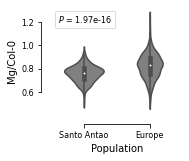

In [8]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

europe=df[df['Population'] == 'Europe']
santoantao=df[df['Population'] == 'SA']

Order=['SA','Europe']

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(6*cm,5*cm))
ax=sns.violinplot(x='Population', 
            y='Mg/Col-0',
            color='grey',
            data=df,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
r,p = mannwhitneyu(europe['Mg/Col-0'],santoantao['Mg/Col-0'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='upper left', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xticklabels(['Santo Antao', 'Europe'])

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
# plt.savefig("FigS8.pdf", format="pdf",bbox_inches="tight",facecolor="w")
# plt.savefig("FigS8.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)